In [43]:
# Import dependencies for analysis

from pathlib import Path
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt


## Import Experimental Data

In [70]:
# Load data into dataframes

home = Path().resolve()

permeance = counter = pd.read_csv(f"{home}/data/permeance_data_collection.csv")
hybrid = pd.read_csv(f"{home}/data/air_separation_run_1.csv")
counter = pd.read_csv(f"{home}/data/air_separation_counter_current_run_1.csv")
co = pd.read_csv(f"{home}/data/air_separation_co_current_run_1.csv")

## Permeance and Selectivity Calculations

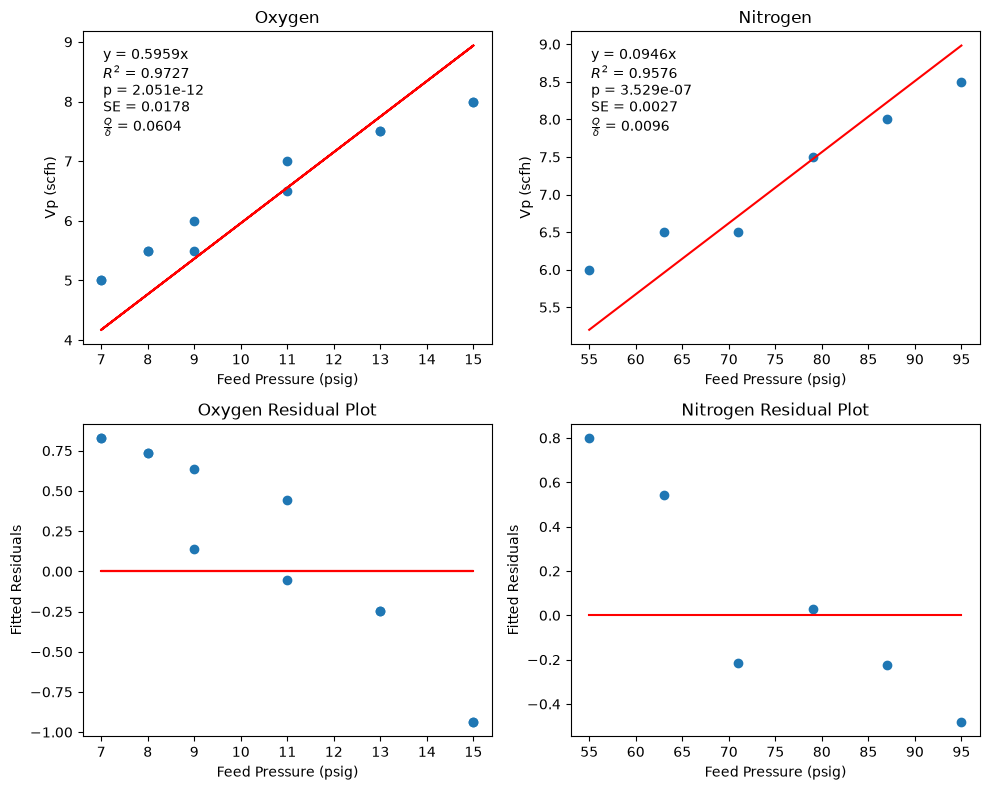

In [59]:
# Calculate permeance and selectivities from permeance dataframe

# Constrained linear regression function (y = mx)
def linest(x: pd.Series, y: pd.Series) -> tuple:
    """
    Linear least-squares regression forced through the origin: y = m*x.

    Returns:
        (slope, intercept, rvalue, pvalue, stderr, intercept_stderr)

    Notes:
        - intercept is always 0.0 because the model is constrained through
          the origin.
        - rvalue is the ordinary Pearson correlation coefficient, matching
          the meaning of scipy.stats.linregress().rvalue.
        - pvalue tests H0: slope = 0 for the no-intercept regression.
        - intercept_stderr is NaN because the intercept is fixed, not estimated.
    """

    # Put x and y together and remove paired NaN values
    data = pd.concat([x, y], axis=1).dropna()

    x = data.iloc[:, 0].to_numpy(dtype=float)
    y = data.iloc[:, 1].to_numpy(dtype=float)

    n = len(x)

    if n < 2:
        raise ValueError("At least two valid x-y pairs are required.")

    # ----- slope for y = mx -----
    sum_x2 = np.sum(x**2)

    if sum_x2 == 0:
        raise ValueError("Cannot perform regression when all x values are zero.")

    slope = np.sum(x * y) / sum_x2

    # ----- intercept -----
    intercept = 0.0

    # ----- residuals -----
    y_pred = slope * x
    residuals = y - y_pred

    # One fitted parameter: slope
    df = n - 1

    # Residual variance
    sse = np.sum(residuals**2)
    mse = sse / df

    # ----- standard error of slope -----
    stderr = np.sqrt(mse / sum_x2)

    # ----- hypothesis test H0: slope = 0 -----
    if stderr == 0:
        if slope == 0:
            pvalue = 1.0
        else:
            pvalue = 0.0
    else:
        t_stat = slope / stderr
        pvalue = 2 * stats.t.sf(np.abs(t_stat), df)

    # ----- Pearson correlation coefficient -----
    rvalue = stats.pearsonr(x, y).statistic

    # Intercept is constrained rather than estimated
    intercept_stderr = np.nan

    return (
        slope,
        intercept,
        rvalue,
        pvalue,
        stderr,
        intercept_stderr
    )

area = 9.86 # Membrane area is 9.86 m^2

# Split into individual species dataframes
oxygen_data = permeance[permeance["Species"] == "O2"]
nitrogen_data = permeance[permeance["Species"] == "N2"]

# Convert oxygen data into long dataframe
oxygen_long = oxygen_data.melt(
    id_vars=["Species", "Feed Pressure (psig)"],
    value_vars=["Vp (scfh), Rep 1", "Vp (scfh), Rep 2"],
    var_name="Replicate",
    value_name="Vp"
)

# Linear regression of y = mx
oxy_reg = linest(oxygen_long["Feed Pressure (psig)"], oxygen_long["Vp"]) 
nitro_reg = linest(nitrogen_data["Feed Pressure (psig)"], nitrogen_data["Vp (scfh), Rep 1"])

# Calculate vector of fitted values
oxy_fit = oxy_reg[0] * oxygen_long["Feed Pressure (psig)"]
nitro_fit = nitro_reg[0] * nitrogen_data["Feed Pressure (psig)"] 

# Calculate residuals of fit
oxy_res = oxygen_long["Vp"] - oxy_fit
nitro_res = nitrogen_data["Vp (scfh), Rep 1"] - nitro_fit

# Declare figures
pnsfig, pnsaxes = plt.subplots(2, 2, figsize=(10, 8))

# Plot oxygen data
pnsaxes[0, 0].scatter(oxygen_long["Feed Pressure (psig)"], oxygen_long["Vp"])
pnsaxes[0, 0].plot(oxygen_long["Feed Pressure (psig)"], oxy_fit, c="red")
pnsaxes[0, 0].set_xlabel("Feed Pressure (psig)")
pnsaxes[0, 0].set_ylabel("Vp (scfh)")
pnsaxes[0, 0].set_title("Oxygen")
oxy_annotations = (
    f"y = {oxy_reg[0]:.4f}x\n"
    f"$R^2$ = {oxy_reg[2]**2:.4f}\n"
    f"p = {oxy_reg[3]:.3e}\n"
    f"SE = {oxy_reg[4]:.4f}\n"
    rf"$\frac{{Q}}{{\delta}}$ = {oxy_reg[0] / area:0.4f}"
)
pnsaxes[0, 0].text(
    0.05, 0.95,
    oxy_annotations,
    transform=pnsaxes[0, 0].transAxes,
    va="top"
)

# Plot nitrogen data
pnsaxes[0, 1].scatter(nitrogen_data["Feed Pressure (psig)"], nitrogen_data["Vp (scfh), Rep 1"])
pnsaxes[0, 1].plot(nitrogen_data["Feed Pressure (psig)"], nitro_fit, c="red")
pnsaxes[0, 1].set_xlabel("Feed Pressure (psig)")
pnsaxes[0, 1].set_ylabel("Vp (scfh)")
pnsaxes[0, 1].set_title("Nitrogen")
oxy_annotations = (
    f"y = {nitro_reg[0]:.4f}x\n"
    f"$R^2$ = {nitro_reg[2]**2:.4f}\n"
    f"p = {nitro_reg[3]:.3e}\n"
    f"SE = {nitro_reg[4]:.4f}\n"
    rf"$\frac{{Q}}{{\delta}}$ = {nitro_reg[0] / area:0.4f}"
)
pnsaxes[0, 1].text(
    0.05, 0.95,
    oxy_annotations,
    transform=pnsaxes[0, 1].transAxes,
    va="top"
)

# Plot residuals for oxygen
pnsaxes[1, 0].scatter(oxygen_long["Feed Pressure (psig)"], oxy_res)
pnsaxes[1, 0].plot(oxygen_long["Feed Pressure (psig)"], oxy_res * 0, c="red")
pnsaxes[1, 0].set_xlabel("Feed Pressure (psig)")
pnsaxes[1, 0].set_ylabel("Fitted Residuals")
pnsaxes[1, 0].set_title("Oxygen Residual Plot")

# Plot residuals for nitrogen
pnsaxes[1, 1].scatter(nitrogen_data["Feed Pressure (psig)"], nitro_res)
pnsaxes[1, 1].plot(nitrogen_data["Feed Pressure (psig)"], nitro_res * 0, c="red")
pnsaxes[1, 1].set_xlabel("Feed Pressure (psig)")
pnsaxes[1, 1].set_ylabel("Fitted Residuals")
pnsaxes[1, 1].set_title("Nitrogen Residual Plot")

pnsfig.tight_layout()
plt.show()

## Full Series Air Separation

Pressure	Slope	Intercept	R2	p		m-stderr	int-stderr
120 psig	-0.3315	0.5260		0.9982	1.280e-06	0.0071		0.0024
100 psig	-0.3267	0.5180		0.9956	7.132e-06	0.0108		0.0036
80 psig		-0.2922	0.4898		0.9873	6.112e-05	0.0166		0.0056
Slope fit	-0.0010	-0.2185		0.8402	0.2618		0.0004		0.0434



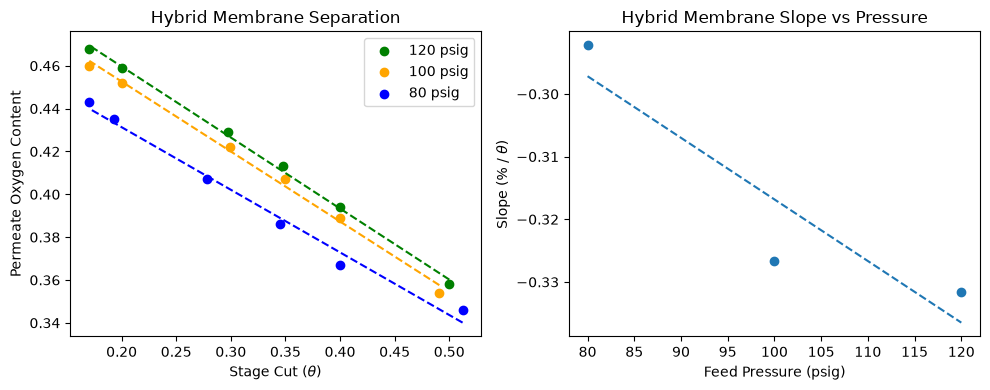

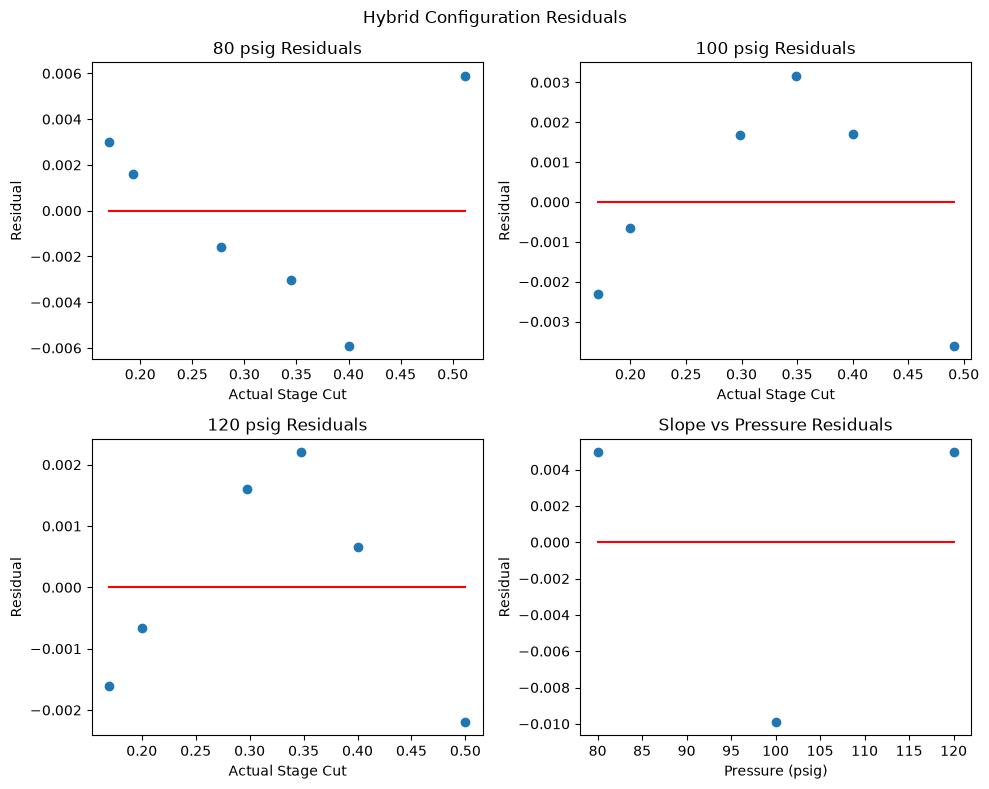

In [ ]:
# This is to analyze the data from the dual hybrid air separation in series

# Declare plot object
hfig, hax = plt.subplots(1, 2, figsize=(10, 4))

# Separate hybrid data into individual pressure series
hp80 = hybrid[hybrid["Feed Pressure (psig) "] == 80]
hp100 = hybrid[hybrid["Feed Pressure (psig) "] == 100]
hp120 = hybrid[hybrid["Feed Pressure (psig) "] == 120]

# Fit the series
hp80reg = stats.linregress(hp80["Actual Stage Cut"], hp80["Permeate O2 Composition (%)"])
hp100reg = stats.linregress(hp100["Actual Stage Cut"], hp100["Permeate O2 Composition (%)"])
hp120reg = stats.linregress(hp120["Actual Stage Cut"], hp120["Permeate O2 Composition (%)"])

# Fit slope versus pressure
hsvspreg = stats.linregress([80, 100, 120], [hp80reg.slope, hp100reg.slope, hp120reg.slope])

# Create fitted vectors
hp80fit = hp80["Actual Stage Cut"] * hp80reg.slope + hp80reg.intercept
hp100fit = hp100["Actual Stage Cut"] * hp100reg.slope + hp100reg.intercept
hp120fit = hp120["Actual Stage Cut"] * hp120reg.slope + hp120reg.intercept

# Created fitted vector for slope vs pressure
hsvspfit = hsvspreg.slope * np.array([80, 100, 120]) + hsvspreg.intercept

# Print out values from regression
print(
    f"Pressure\tSlope\tIntercept\tR2\tp\t\tm-stderr\tint-stderr\n"
    f"120 psig\t{hp120reg.slope:.4f}\t{hp120reg.intercept:.4f}\t\t{hp120reg.rvalue**2:.4f}\t{hp120reg.pvalue:.3e}\t{hp120reg.stderr:.4f}\t\t{hp120reg.intercept_stderr:.4f}\n"
    f"100 psig\t{hp100reg.slope:.4f}\t{hp100reg.intercept:.4f}\t\t{hp100reg.rvalue**2:.4f}\t{hp100reg.pvalue:.3e}\t{hp100reg.stderr:.4f}\t\t{hp100reg.intercept_stderr:.4f}\n"
    f"80 psig\t\t{hp80reg.slope:.4f}\t{hp80reg.intercept:.4f}\t\t{hp80reg.rvalue**2:.4f}\t{hp80reg.pvalue:.3e}\t{hp80reg.stderr:.4f}\t\t{hp80reg.intercept_stderr:.4f}\n"
    f"Slope fit\t{hsvspreg.slope:.4f}\t{hsvspreg.intercept:.4f}\t\t{hsvspreg.rvalue**2:.4f}\t{hsvspreg.pvalue:.4f}\t\t{hsvspreg.stderr:.4f}\t\t{hsvspreg.intercept_stderr:.4f}\n"   
)

# Plot the observed data ** Order of plotting masters for visual clarity (order on the legend)
hax[0].scatter(hp120["Actual Stage Cut"], hp120["Permeate O2 Composition (%)"], label="120 psig", c="green")
hax[0].scatter(hp100["Actual Stage Cut"], hp100["Permeate O2 Composition (%)"], label="100 psig", c="orange")
hax[0].scatter(hp80["Actual Stage Cut"], hp80["Permeate O2 Composition (%)"], label="80 psig", c="blue")

# Plot fitted data
hax[0].plot(hp80["Actual Stage Cut"], hp80fit, c="blue", ls="--")
hax[0].plot(hp100["Actual Stage Cut"], hp100fit, c="orange", ls="--")
hax[0].plot(hp120["Actual Stage Cut"], hp120fit, c="green", ls="--")

# Label the chart
hax[0].set_xlabel(rf"Stage Cut ($\theta$)")
hax[0].set_ylabel("Permeate Oxygen Content")
hax[0].set_title("Hybrid Membrane Separation")
hax[0].legend()

# Plot separation slope vs pressure
hax[1].scatter([80, 100, 120], [hp80reg.slope, hp100reg.slope, hp120reg.slope])
hax[1].plot([80, 100, 120], hsvspfit, ls="--")
hax[1].set_xlabel("Feed Pressure (psig)")
hax[1].set_ylabel(rf"Slope (% / $\theta$)")
hax[1].set_title("Hybrid Membrane Slope vs Pressure")

# Fix formatting
hfig.tight_layout()

# Calculate Residuals
hp80res = hp80["Permeate O2 Composition (%)"] - hp80fit
hp100res = hp100["Permeate O2 Composition (%)"] - hp100fit
hp120res = hp120["Permeate O2 Composition (%)"] - hp120fit
hpsvspres = np.array([hp80reg.slope, hp100reg.slope, hp120reg.slope]) - hsvspfit

### Plot residuals ###
hrfig, hraxes = plt.subplots(2, 2, figsize=(10, 8))

# 80 psig residuals
hraxes[0, 0].scatter(hp80["Actual Stage Cut"], hp80res)
hraxes[0, 0].plot(hp80["Actual Stage Cut"], hp80res * 0, c="red")
hraxes[0, 0].set_xlabel("Actual Stage Cut")
hraxes[0, 0].set_ylabel("Residual")
hraxes[0, 0].set_title("80 psig")

# 100 psig residuals
hraxes[0, 1].scatter(hp100["Actual Stage Cut"], hp100res)
hraxes[0, 1].plot(hp100["Actual Stage Cut"], 0 * hp100res, c="red")
hraxes[0, 1].set_xlabel("Actual Stage Cut")
hraxes[0, 1].set_ylabel("Residual")
hraxes[0, 1].set_title("100 psig")

# 120 psig residuals
hraxes[1, 0].scatter(hp120["Actual Stage Cut"], hp120res)
hraxes[1, 0].plot(hp120["Actual Stage Cut"], 0 * hp120res, c="red")
hraxes[1, 0].set_xlabel("Actual Stage Cut")
hraxes[1, 0].set_ylabel("Residual")
hraxes[1, 0].set_title("120 psig")

# Slope vs pressure residuals
hraxes[1, 1].scatter([80, 100, 120], hpsvspres)
hraxes[1, 1].plot([80, 100, 120], 0 * hpsvspres, c="red")
hraxes[1, 1].set_xlabel("Pressure (psig)")
hraxes[1, 1].set_ylabel("Residual")
hraxes[1, 1].set_title("Slope vs Pressure")

hrfig.suptitle("Hybrid Configuration Residuals")
hrfig.tight_layout()

plt.show()

## Counter-Current Air Separation

Pressure	Slope	Intercept	R2	p		m-stderr	int-stderr
120 psig	-0.3548	0.5519		0.9940	2.983e-03	0.0194		0.0051
100 psig	-0.3333	0.5371		0.9984	8.252e-04	0.0096		0.0026
80 psig		-0.2881	0.5194		0.9982	8.787e-04	0.0085		0.0023
Slope fit	-0.0017	-0.1588		0.9594	0.1291		0.0003		0.0347



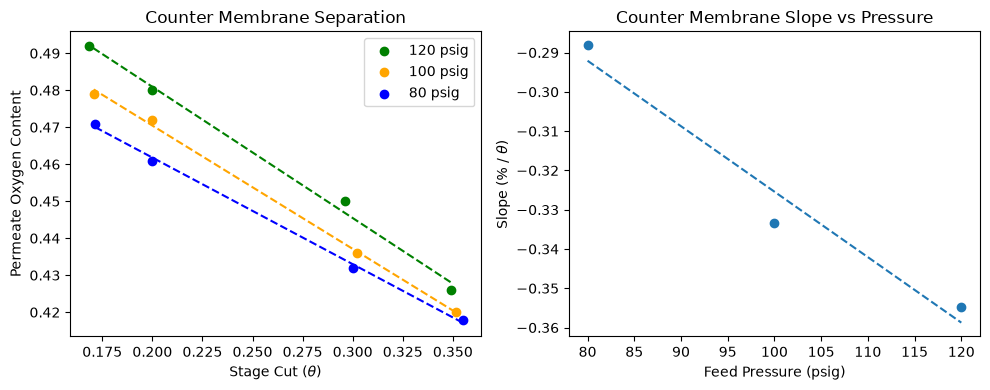

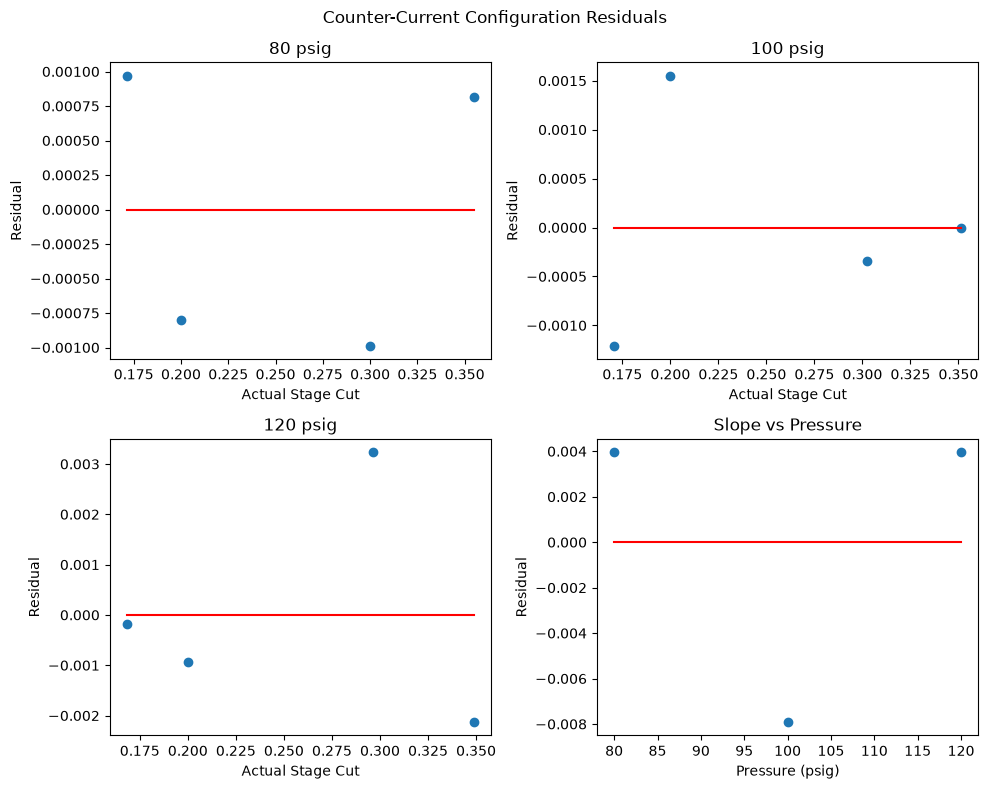

In [132]:
# This is to analyze the data from the counter current air separation in series

# Declare plot object
cnfig, cnax = plt.subplots(1, 2, figsize=(10, 4))

# Separate counter data into individual pressure series
cnp80 = counter[counter["Feed Pressure (psig) "] == 80]
cnp100 = counter[counter["Feed Pressure (psig) "] == 100]
cnp120 = counter[counter["Feed Pressure (psig) "] == 120]

# Fit the series
cnp80reg = stats.linregress(cnp80["Actual Stage Cut"], cnp80["Permeate O2 Composition (%)"])
cnp100reg = stats.linregress(cnp100["Actual Stage Cut"], cnp100["Permeate O2 Composition (%)"])
cnp120reg = stats.linregress(cnp120["Actual Stage Cut"], cnp120["Permeate O2 Composition (%)"])

# Fit slope versus pressure to gauge
cnsvspreg = stats.linregress([80, 100, 120], [cnp80reg.slope, cnp100reg.slope, cnp120reg.slope])

# Create fitted vectors
cnp80fit = cnp80["Actual Stage Cut"] * cnp80reg.slope + cnp80reg.intercept
cnp100fit = cnp100["Actual Stage Cut"] * cnp100reg.slope + cnp100reg.intercept
cnp120fit = cnp120["Actual Stage Cut"] * cnp120reg.slope + cnp120reg.intercept

# Created fitted vector for slope vs pressure
cnsvspfit = cnsvspreg.slope * np.array([80, 100, 120]) + cnsvspreg.intercept

# Print out values from regression
print(
    f"Pressure\tSlope\tIntercept\tR2\tp\t\tm-stderr\tint-stderr\n"
    f"120 psig\t{cnp120reg.slope:.4f}\t{cnp120reg.intercept:.4f}\t\t{cnp120reg.rvalue**2:.4f}\t{cnp120reg.pvalue:.3e}\t{cnp120reg.stderr:.4f}\t\t{cnp120reg.intercept_stderr:.4f}\n"
    f"100 psig\t{cnp100reg.slope:.4f}\t{cnp100reg.intercept:.4f}\t\t{cnp100reg.rvalue**2:.4f}\t{cnp100reg.pvalue:.3e}\t{cnp100reg.stderr:.4f}\t\t{cnp100reg.intercept_stderr:.4f}\n"
    f"80 psig\t\t{cnp80reg.slope:.4f}\t{cnp80reg.intercept:.4f}\t\t{cnp80reg.rvalue**2:.4f}\t{cnp80reg.pvalue:.3e}\t{cnp80reg.stderr:.4f}\t\t{cnp80reg.intercept_stderr:.4f}\n"
    f"Slope fit\t{cnsvspreg.slope:.4f}\t{cnsvspreg.intercept:.4f}\t\t{cnsvspreg.rvalue**2:.4f}\t{cnsvspreg.pvalue:.4f}\t\t{cnsvspreg.stderr:.4f}\t\t{cnsvspreg.intercept_stderr:.4f}\n"   
)

# Plot the observed data ** Order of plotting masters for visual clarity (order on the legend)
cnax[0].scatter(cnp120["Actual Stage Cut"], cnp120["Permeate O2 Composition (%)"], label="120 psig", c="green")
cnax[0].scatter(cnp100["Actual Stage Cut"], cnp100["Permeate O2 Composition (%)"], label="100 psig", c="orange")
cnax[0].scatter(cnp80["Actual Stage Cut"], cnp80["Permeate O2 Composition (%)"], label="80 psig", c="blue")

# Plot fitted data
cnax[0].plot(cnp80["Actual Stage Cut"], cnp80fit, c="blue", ls="--")
cnax[0].plot(cnp100["Actual Stage Cut"], cnp100fit, c="orange", ls="--")
cnax[0].plot(cnp120["Actual Stage Cut"], cnp120fit, c="green", ls="--")

# Label the chart
cnax[0].set_xlabel(rf"Stage Cut ($\theta$)")
cnax[0].set_ylabel("Permeate Oxygen Content")
cnax[0].set_title("Counter Membrane Separation")
cnax[0].legend()

# Plot separation slope vs pressure
cnax[1].scatter([80, 100, 120], [cnp80reg.slope, cnp100reg.slope, cnp120reg.slope])
cnax[1].plot([80, 100, 120], cnsvspfit, ls="--")
cnax[1].set_xlabel("Feed Pressure (psig)")
cnax[1].set_ylabel(rf"Slope (% / $\theta$)")
cnax[1].set_title("Counter Membrane Slope vs Pressure")

cnfig.tight_layout()

# Calculate Residuals
cnp80res = cnp80["Permeate O2 Composition (%)"] - cnp80fit
cnp100res = cnp100["Permeate O2 Composition (%)"] - cnp100fit
cnp120res = cnp120["Permeate O2 Composition (%)"] - cnp120fit
cnpsvspres = np.array([cnp80reg.slope, cnp100reg.slope, cnp120reg.slope]) - cnsvspfit

### Plot residuals ###
cnrfig, cnraxes = plt.subplots(2, 2, figsize=(10, 8))

# 80 psig residuals
cnraxes[0, 0].scatter(cnp80["Actual Stage Cut"], cnp80res)
cnraxes[0, 0].plot(cnp80["Actual Stage Cut"], cnp80res * 0, c="red")
cnraxes[0, 0].set_xlabel("Actual Stage Cut")
cnraxes[0, 0].set_ylabel("Residual")
cnraxes[0, 0].set_title("80 psig")

# 100 psig residuals
cnraxes[0, 1].scatter(cnp100["Actual Stage Cut"], cnp100res)
cnraxes[0, 1].plot(cnp100["Actual Stage Cut"], 0 * cnp100res, c="red")
cnraxes[0, 1].set_xlabel("Actual Stage Cut")
cnraxes[0, 1].set_ylabel("Residual")
cnraxes[0, 1].set_title("100 psig")

# 120 psig residuals
cnraxes[1, 0].scatter(cnp120["Actual Stage Cut"], cnp120res)
cnraxes[1, 0].plot(cnp120["Actual Stage Cut"], 0 * cnp120res, c="red")
cnraxes[1, 0].set_xlabel("Actual Stage Cut")
cnraxes[1, 0].set_ylabel("Residual")
cnraxes[1, 0].set_title("120 psig")

# Slope vs pressure residuals
cnraxes[1, 1].scatter([80, 100, 120], cnpsvspres)
cnraxes[1, 1].plot([80, 100, 120], 0 * cnpsvspres, c="red")
cnraxes[1, 1].set_xlabel("Pressure (psig)")
cnraxes[1, 1].set_ylabel("Residual")
cnraxes[1, 1].set_title("Slope vs Pressure")

cnrfig.suptitle("Counter-Current Configuration Residuals")
cnrfig.tight_layout()

plt.show()

## Co-Current Air Separation

Pressure	Slope	Intercept	R2	p		m-stderr	int-stderr
120 psig	-0.3165	0.5062		0.9991	4.386e-04	0.0066		0.0018
100 psig	-0.2670	0.4795		0.9842	7.920e-03	0.0239		0.0063
80 psig		-0.2462	0.4667		0.9981	9.592e-04	0.0076		0.0020
Slope fit	-0.0018	-0.1010		0.9473	0.1474		0.0004		0.0420



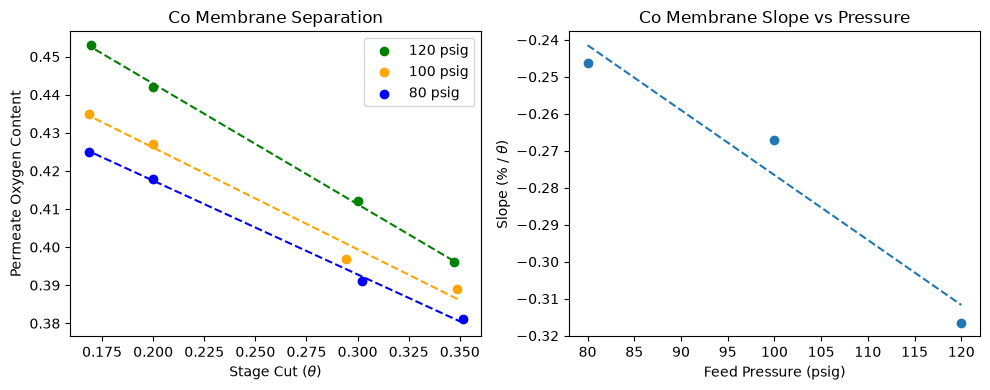

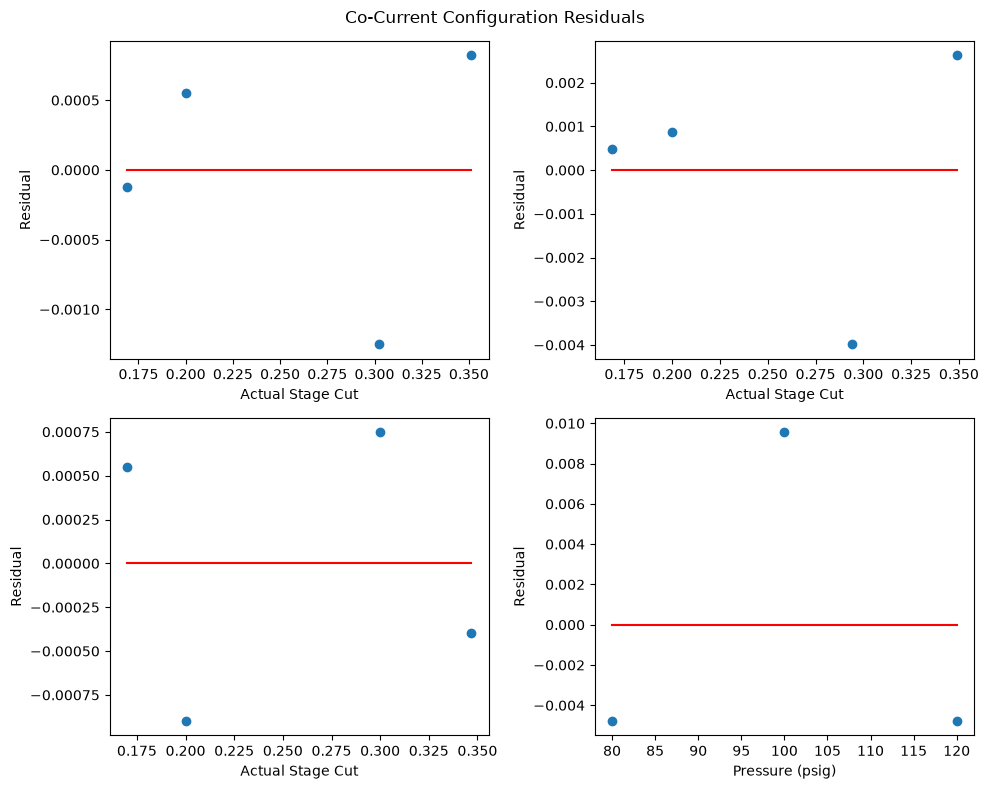

In [ ]:
# This is to analyze the data from the counter current air separation in series

# Declare plot object
cfig, cax = plt.subplots(1, 2, figsize=(10, 4))

# Separate co data into individual pressure series
cp80 = co[co["Feed Pressure (psig) "] == 80]
cp100 = co[co["Feed Pressure (psig) "] == 100]
cp120 = co[co["Feed Pressure (psig) "] == 120]

# Fit the series
cp80reg = stats.linregress(cp80["Actual Stage Cut"], cp80["Permeate O2 Composition (%)"])
cp100reg = stats.linregress(cp100["Actual Stage Cut"], cp100["Permeate O2 Composition (%)"])
cp120reg = stats.linregress(cp120["Actual Stage Cut"], cp120["Permeate O2 Composition (%)"])

# Fit slope versus pressure to gauge
csvspreg = stats.linregress([80, 100, 120], [cp80reg.slope, cp100reg.slope, cp120reg.slope])

# Create fitted vectors
cp80fit = cp80["Actual Stage Cut"] * cp80reg.slope + cp80reg.intercept
cp100fit = cp100["Actual Stage Cut"] * cp100reg.slope + cp100reg.intercept
cp120fit = cp120["Actual Stage Cut"] * cp120reg.slope + cp120reg.intercept

# Created fitted vector for slope vs pressure
csvspfit = csvspreg.slope * np.array([80, 100, 120]) + csvspreg.intercept

# Print out values from regression
print(
    f"Pressure\tSlope\tIntercept\tR2\tp\t\tm-stderr\tint-stderr\n"
    f"120 psig\t{cp120reg.slope:.4f}\t{cp120reg.intercept:.4f}\t\t{cp120reg.rvalue**2:.4f}\t{cp120reg.pvalue:.3e}\t{cp120reg.stderr:.4f}\t\t{cp120reg.intercept_stderr:.4f}\n"
    f"100 psig\t{cp100reg.slope:.4f}\t{cp100reg.intercept:.4f}\t\t{cp100reg.rvalue**2:.4f}\t{cp100reg.pvalue:.3e}\t{cp100reg.stderr:.4f}\t\t{cp100reg.intercept_stderr:.4f}\n"
    f"80 psig\t\t{cp80reg.slope:.4f}\t{cp80reg.intercept:.4f}\t\t{cp80reg.rvalue**2:.4f}\t{cp80reg.pvalue:.3e}\t{cp80reg.stderr:.4f}\t\t{cp80reg.intercept_stderr:.4f}\n"
    f"Slope fit\t{csvspreg.slope:.4f}\t{csvspreg.intercept:.4f}\t\t{csvspreg.rvalue**2:.4f}\t{csvspreg.pvalue:.4f}\t\t{csvspreg.stderr:.4f}\t\t{csvspreg.intercept_stderr:.4f}\n" 
)

# Plot the observed data ** Order of plotting masters for visual clarity (order on the legend)
cax[0].scatter(cp120["Actual Stage Cut"], cp120["Permeate O2 Composition (%)"], label="120 psig", c="green")
cax[0].scatter(cp100["Actual Stage Cut"], cp100["Permeate O2 Composition (%)"], label="100 psig", c="orange")
cax[0].scatter(cp80["Actual Stage Cut"], cp80["Permeate O2 Composition (%)"], label="80 psig", c="blue")

# Plot fitted data
cax[0].plot(cp80["Actual Stage Cut"], cp80fit, c="blue", ls="--")
cax[0].plot(cp100["Actual Stage Cut"], cp100fit, c="orange", ls="--")
cax[0].plot(cp120["Actual Stage Cut"], cp120fit, c="green", ls="--")

# Label the chart
cax[0].set_xlabel(rf"Stage Cut ($\theta$)")
cax[0].set_ylabel("Permeate Oxygen Content")
cax[0].set_title("Co Membrane Separation")
cax[0].legend()

# Plot separation slope vs pressure
cax[1].scatter([80, 100, 120], [cp80reg.slope, cp100reg.slope, cp120reg.slope])
cax[1].plot([80, 100, 120], csvspfit, ls="--")
cax[1].set_xlabel("Feed Pressure (psig)")
cax[1].set_ylabel(rf"Slope (% / $\theta$)")
cax[1].set_title("Co Membrane Slope vs Pressure")

cfig.tight_layout()

# Calculate Residuals
cp80res = cp80["Permeate O2 Composition (%)"] - cp80fit
cp100res = cp100["Permeate O2 Composition (%)"] - cp100fit
cp120res = cp120["Permeate O2 Composition (%)"] - cp120fit
cpsvspres = np.array([cp80reg.slope, cp100reg.slope, cp120reg.slope]) - csvspfit

### Plot residuals ###
crfig, craxes = plt.subplots(2, 2, figsize=(10, 8))

# 80 psig residuals
craxes[0, 0].scatter(cp80["Actual Stage Cut"], cp80res)
craxes[0, 0].plot(cp80["Actual Stage Cut"], cp80res * 0, c="red")
craxes[0, 0].set_xlabel("Actual Stage Cut")
craxes[0, 0].set_ylabel("Residual")
craxes[0, 0].set_title("80 psig")

# 100 psig residuals
craxes[0, 1].scatter(cp100["Actual Stage Cut"], cp100res)
craxes[0, 1].plot(cp100["Actual Stage Cut"], 0 * cp100res, c="red")
craxes[0, 1].set_xlabel("Actual Stage Cut")
craxes[0, 1].set_ylabel("Residual")
craxes[0, 1].set_title("100 psig")

# 120 psig residuals
craxes[1, 0].scatter(cp120["Actual Stage Cut"], cp120res)
craxes[1, 0].plot(cp120["Actual Stage Cut"], 0 * cp120res, c="red")
craxes[1, 0].set_xlabel("Actual Stage Cut")
craxes[1, 0].set_ylabel("Residual")
craxes[1, 0].set_title("120 psig")

# Slope vs pressure residuals
craxes[1, 1].scatter([80, 100, 120], cpsvspres)
craxes[1, 1].plot([80, 100, 120], 0 * cpsvspres, c="red")
craxes[1, 1].set_xlabel("Pressure (psig)")
craxes[1, 1].set_ylabel("Residual")
craxes[1, 1].set_title("Slope vs Pressure")

crfig.suptitle("Co-Current Configuration Residuals")
crfig.tight_layout()

plt.show()